## Refinement on-the-fly of ensemble and forward model
described in the Chapter 3 of the Thesis

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, copy, os

In [2]:
import sys
sys.path.append('../')

from simpleMD import generate_chain, SimpleMD

### 1. MD simulation for the prior model
run a new simulation or load pre-existing simulation from `data`

In [3]:
cell = (100., 100., 100.)
positions = generate_chain(10, 1.)

In [ ]:
keys_prior = {
 'temperature': 0.722,
 'tstep': 0.001,
 'friction': 1.0,
 'forcecutoff': 2.5,
 'k_fene': 30.0,
 'maxbond': 1.5,
 'q_SAXS': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
 'listcutoff': 3.0,
 'nstep': 1000000,
 'nconfig': 1000,
 'nstat': 100,
 'nequilib':10000
 }

# generate a crystal lattice and pass it:
keys_prior["cell"] = cell
keys_prior["positions"] = positions


In [5]:
is_run = False

In [6]:
if is_run:
    # create runner
    smd_prior=SimpleMD(**keys_prior)
    # run
    smd_prior.run()
else:
    with open("../data/prior.pkl", "rb") as file:
        smd_prior = pickle.load(file)

### 2. MD simulation for the reference model

In [11]:
keys_test = copy.deepcopy(keys_prior)

keys_test.update({
    'k_angle' : 5.0,
    'nconfig' : 100,
    'nstat' : 10
})

In [13]:
if is_run:
    # create runner
    smd_test=SimpleMD(**keys_test)
    # run
    smd_test.run()
else:
    with open("../data/test.pkl", "rb") as file:
        smd_test = pickle.load(file)

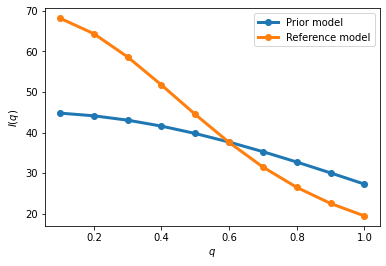

In [14]:
plt.plot(smd_prior.q_SAXS, smd_prior.SAXS, 'o-', label='Prior model', linewidth=3)
plt.plot(smd_test.q_SAXS, 1.5*smd_test.SAXS + 2.0, 'o-', label='Reference model', linewidth=3)
plt.legend()
plt.xlabel(r'$q$')
plt.ylabel(r'$I(q)$')
plt.show()

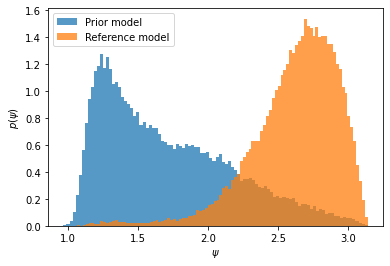

In [15]:
plt.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
plt.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Reference model')
plt.legend()
plt.xlabel(r'$\psi$')
plt.ylabel(r'$p(\psi)$')
plt.show()

### 3. refinement

#### try different values for the parameters

In [54]:
keys_0 = copy.deepcopy(keys_prior)

keys_0.update({
    'k_fm' : [1.0, 0.2],
    'tau_fm' : 50000.0,
    
    'exp_SAXS' : 1.5*smd_test.SAXS + 2.0,
    'sigma_SAXS' : [1.0],
    'k_SAXS' : 0.2,
    'tau_SAXS' : 50000.0,

    'l_rgyr2' : 0.0,
    'nonthefly' : int(2e6),
    'nstep' : int(3.01e6)
})

In [56]:
keys_1 = copy.deepcopy(keys_0)
keys_1['k_fm'] = [0.1, 0.02]

keys_2 = copy.deepcopy(keys_0)
keys_2['k_fm'] = [0.01, 0.002]

keys_3 = copy.deepcopy(keys_0)
keys_3['k_fm'] = [1e-3, 2e-4]

keys_4 = copy.deepcopy(keys_0)
keys_4['k_fm'] = [0.1, 0.2]

In [57]:
keys_fm = [keys_0, keys_1, keys_2, keys_3, keys_4]
smd_fm = {}

if is_run:
    for i in range(5):
        smd_fm[i] = SimpleMD(**keys_fm[i])
        smd_fm[i].run()
else:
    folder_path = "../data/"
    file_names = [
        "posterior_0.2_1.0_0.2_50000",
        "posterior_0.2_0.1_0.02_50000",
        "posterior_0.2_0.01_0.002_50000",
        "posterior_0.2_0.001_0.0002_50000",
        "posterior_0.2_0.1_2.0_50000"
    ]

    for i in range(len(file_names)):
        try:
            with open(os.path.join(folder_path, file_names[0] + ".pkl"), "rb") as file:
                smd_fm[i] = pickle.load(file)
            print(f"Successfully loaded {file_names[0]} as smd_fm0")
        except FileNotFoundError:
            print(f"Error: File not found - {file_names[0]}.pkl")

Successfully loaded posterior_0.2_1.0_0.2_50000 as smd_fm0
Successfully loaded posterior_0.2_1.0_0.2_50000 as smd_fm0
Successfully loaded posterior_0.2_1.0_0.2_50000 as smd_fm0
Successfully loaded posterior_0.2_1.0_0.2_50000 as smd_fm0
Successfully loaded posterior_0.2_1.0_0.2_50000 as smd_fm0


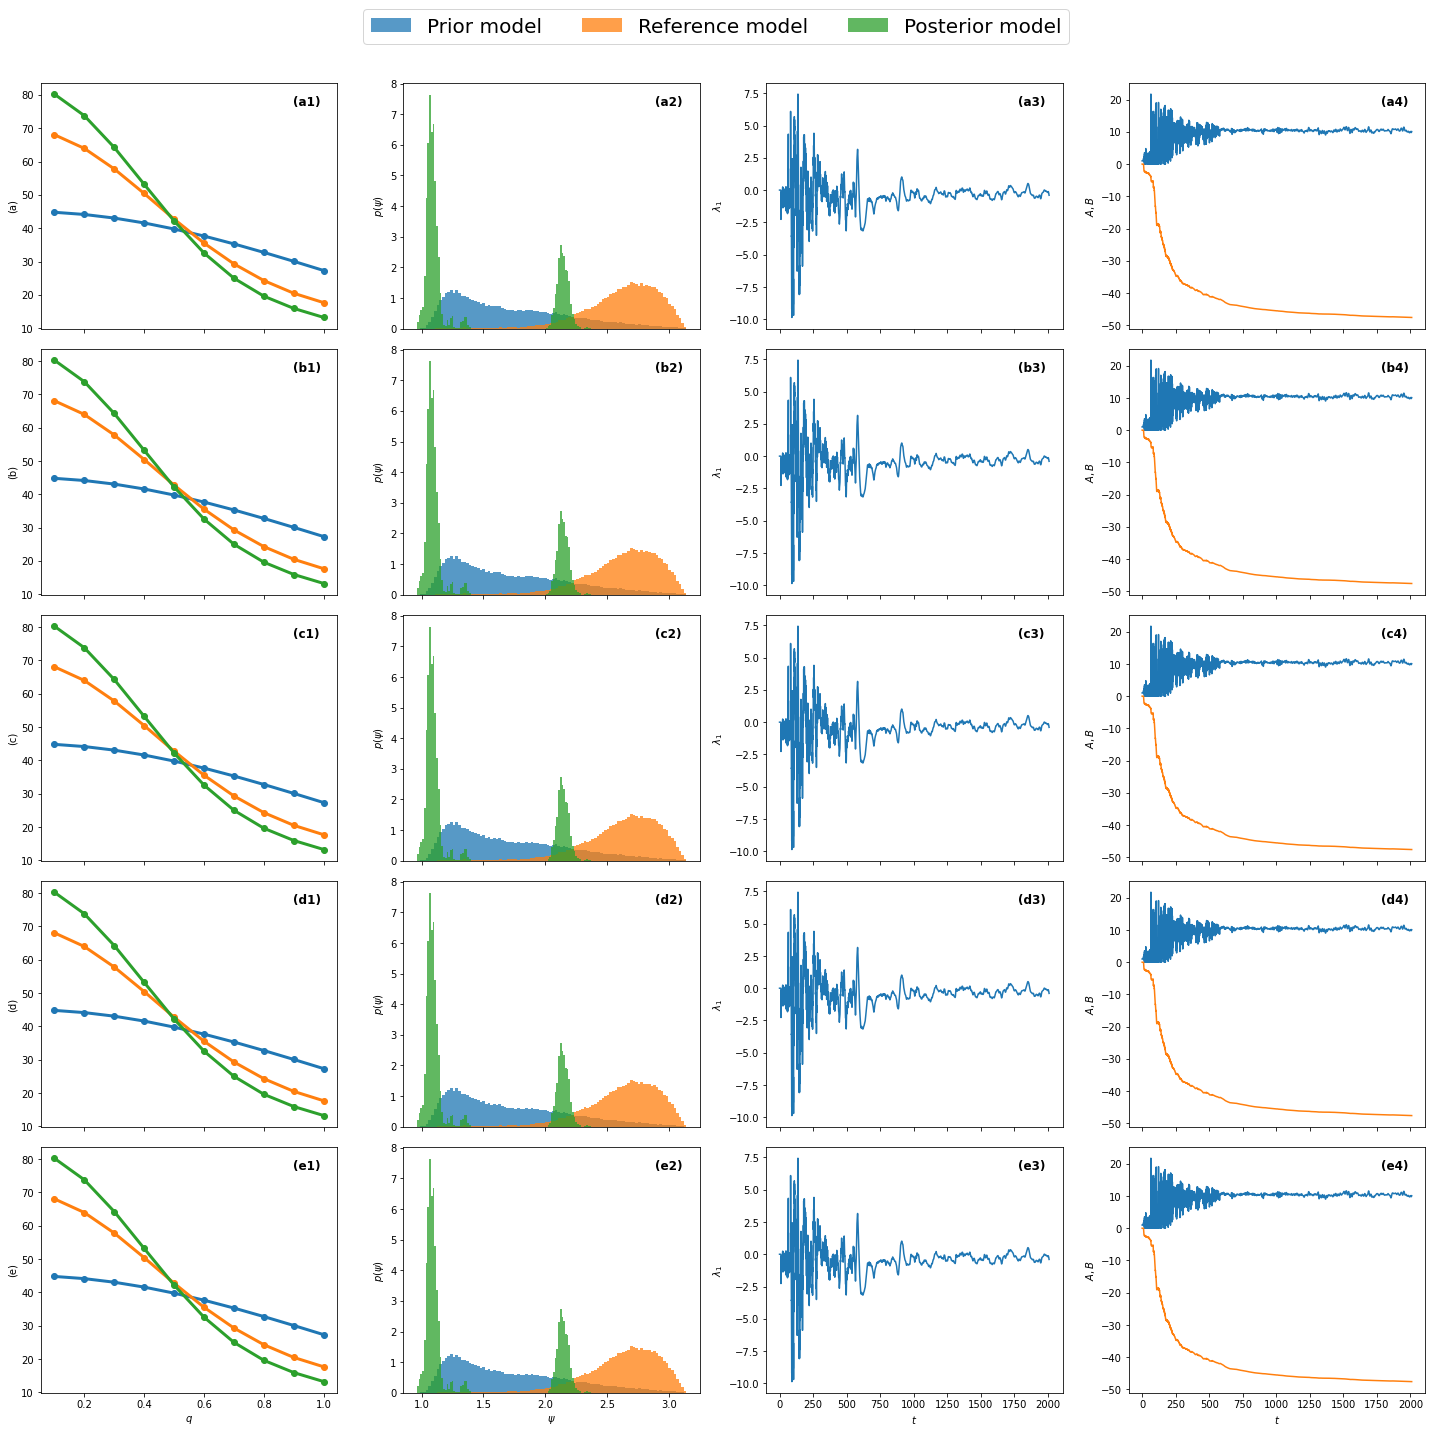

In [58]:
simulations = ["(a)", "(b)", "(c)", "(d)", "(e)"]
image_types = ["Tipo1", "Tipo2", "Tipo3", "Tipo4"]
labels = [['(a1)','(a2)','(a3)', '(a4)'], ['(b1)','(b2)','(b3)', '(b4)'], ['(c1)','(c2)','(c3)', '(c4)'], ['(d1)','(d2)','(d3)', '(d4)'], ['(e1)','(e2)','(e3)','(e4)']] # Etichette per ogni subplot


fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20), sharex="col")


for i, sim in enumerate(simulations):
  for j, img_type in enumerate(image_types):
    ax = axes[i, j]

    if j == 0:
      if i==0:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_fm[0].exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_fm[0].q_SAXS, smd_fm[0].SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')

      elif i==1:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_fm[1].exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_fm[1].q_SAXS, smd_fm[1].SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')


      elif i==2:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_fm[2].exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_fm[2].q_SAXS, smd_fm[2].SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')

      elif i==3:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_fm[3].exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_fm[3].q_SAXS, smd_fm[3].SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')

      elif i==4:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_fm[4].exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_fm[4].q_SAXS, smd_fm[4].SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')
      
      if j == 0:
        ax.set_ylabel(sim)
    elif j == 1: 
        if i == 0: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Reference model')
            ax.hist(smd_fm[0].angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model')
            ax.set_ylabel(r'$p(\psi)$')
            
        elif i == 1: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_fm[1].angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_ylabel(r'$p(\psi)$')
            
        elif i == 2: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_fm[2].angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_ylabel(r'$p(\psi)$')

        elif i == 3: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_fm[3].angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_ylabel(r'$p(\psi)$')

        elif i == 4: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_fm[4].angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_ylabel(r'$p(\psi)$')

        
    elif j == 2: 
        if i == 0:
            ax.plot(np.array(smd_fm[0].statistics).T[1][:20100],smd_fm[0].lambda_otf[0][:20100])
            ax.set_ylabel(r'$\lambda_1$')
            
        elif i == 1:
            ax.plot(np.array(smd_fm[1].statistics).T[1][:20100],smd_fm[1].lambda_otf[0][:20100])
            ax.set_ylabel(r'$\lambda_1$')
        elif i == 2:
            ax.plot(np.array(smd_fm[2].statistics).T[1][:20100],smd_fm[2].lambda_otf[0][:20100])
            ax.set_ylabel(r'$\lambda_1$')

        elif i == 3:
          ax.plot(np.array(smd_fm[3].statistics).T[1][:20100],smd_fm[3].lambda_otf[0][:20100])
          ax.set_ylabel(r'$\lambda_1$')

        elif i == 4:
          ax.plot(np.array(smd_fm[4].statistics).T[1][:20100],smd_fm[4].lambda_otf[0][:20100])
          ax.set_ylabel(r'$\lambda_1$')

    elif j == 3: 
        if i == 0:
          ax.plot(np.array(smd_fm[0].statistics).T[1][:20100],smd_fm[0].fm_otf[0][:20100])
          ax.plot(np.array(smd_fm[0].statistics).T[1][:20100],smd_fm[0].fm_otf[1][:20100])
          ax.set_ylabel(r'$A,B$')
              
        elif i == 1:
          ax.plot(np.array(smd_fm[1].statistics).T[1][:20100],smd_fm[1].fm_otf[0][:20100])
          ax.plot(np.array(smd_fm[1].statistics).T[1][:20100],smd_fm[1].fm_otf[1][:20100])
          ax.set_ylabel(r'$A,B$')
        elif i == 2:
          ax.plot(np.array(smd_fm[2].statistics).T[1][:20100],smd_fm[2].fm_otf[0][:20100])
          ax.plot(np.array(smd_fm[2].statistics).T[1][:20100],smd_fm[2].fm_otf[1][:20100])
          ax.set_ylabel(r'$A,B$')

        elif i == 3:
          ax.plot(np.array(smd_fm[3].statistics).T[1][:20100],smd_fm[3].fm_otf[0][:20100])
          ax.plot(np.array(smd_fm[3].statistics).T[1][:20100],smd_fm[3].fm_otf[1][:20100])
          ax.set_ylabel(r'$A,B$')

        elif i == 4:
          ax.plot(np.array(smd_fm[4].statistics).T[1][:20100],smd_fm[4].fm_otf[0][:20100])
          ax.plot(np.array(smd_fm[4].statistics).T[1][:20100],smd_fm[4].fm_otf[1][:20100])
          ax.set_ylabel(r'$A,B$')




    # Add custom label at the top left of the subplot
    ax.text(0.85, 0.95, labels[i][j], transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')



axes[-1, 0].set_xlabel(r'$q$')
axes[-1, 1].set_xlabel(r'$\psi$')
axes[-1, 2].set_xlabel(r'$t$')
axes[-1, 3].set_xlabel(r'$t$')


handles, labels_legend = axes[0,1].get_legend_handles_labels() 
fig.legend(handles, labels_legend, loc="upper center", ncol=3,fontsize=20)


plt.tight_layout(rect=[0,0,1,0.95])
# plt.savefig('fmtab.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### choose a set of values for the parameters

In [ ]:
keys_posterior = keys_1
# here I don't modify the values of keys_posterior, so I can use the same memory reference during copy

In [ ]:
if not is_run: name = file_names[1]

In [71]:
if is_run:
    # create runner
    smd_posterior = SimpleMD(**keys_posterior)
    # run
    smd_posterior.run()
else:
    with open("../data/" + name + ".pkl", "rb") as file:
        smd_posterior = pickle.load(file)

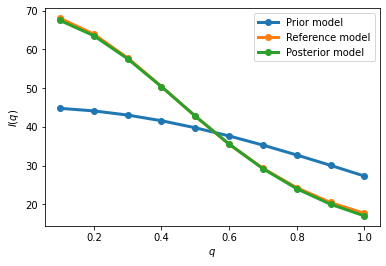

In [72]:
plt.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
plt.plot(smd_posterior.q_SAXS, smd_posterior.exp_SAXS, '-o', label='Reference model',linewidth=3)
plt.plot(smd_posterior.q_SAXS, smd_posterior.SAXS, '-o', label='Posterior model',linewidth=3)
plt.legend()
plt.xlabel(r'$q$')
plt.ylabel(r'$I(q)$')


# plt.savefig('SAXSlfinal.pdf', format='pdf', bbox_inches='tight')

plt.show()

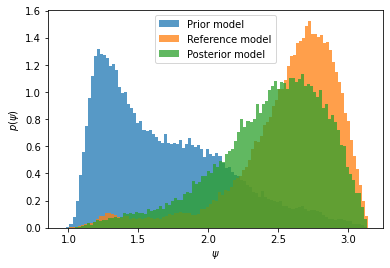

In [73]:
ndata = smd_posterior.nstep - smd_posterior.nonthefly - smd_posterior.nequilib  # data collection phase

plt.hist(smd_prior.angle[3], bins=100, density=True, alpha=0.75, label='Prior model')
plt.hist(smd_test.angle[3], bins=100, density=True, alpha=0.75, label='Reference model')
plt.hist(smd_posterior.angle[3][-ndata:], bins=100, density=True, alpha=0.75, label='Posterior model')
plt.xlabel(r'$\psi$')
plt.ylabel(r'$p(\psi)$')
plt.legend()


plt.show()

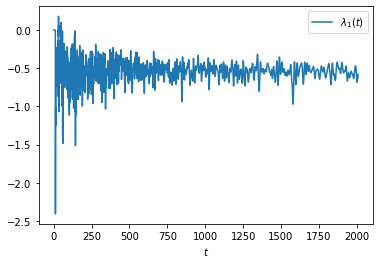

In [74]:
t = np.array(smd_posterior.statistics).T[1][:-ndata//smd_posterior.nstat]
lambda0 = smd_posterior.lambda_otf[0][:-ndata//smd_posterior.nstat]

plt.plot(t, lambda0, label=r"$\lambda_1(t)$")
plt.legend()
plt.xlabel(r'$t$')
# plt.savefig('lfinal.pdf', format='pdf', bbox_inches='tight')
plt.show()


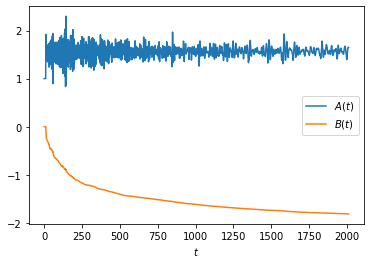

In [75]:
fm = [smd_posterior.fm_otf[0][:-ndata//smd_posterior.nstat],
      smd_posterior.fm_otf[1][:-ndata//smd_posterior.nstat]]

plt.plot(t, fm[0], label=r'$A(t)$')
plt.plot(t, fm[1], label=r'$B(t)$')
plt.legend()
plt.xlabel(r'$t$')
plt.show()

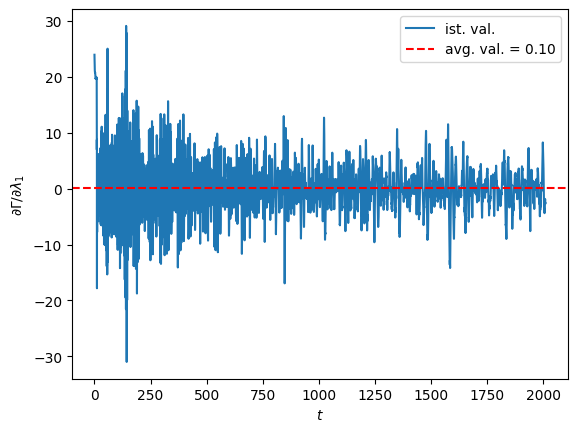

In [ ]:
grad_lambda = smd_posterior.grad_lambda[1][:-ndata//smd_posterior.nstat]

plt.plot(t, grad_lambda, label="ist. val.")

avg=np.mean(grad_lambda)
plt.axhline(y=avg, color="r", linestyle="--", label=f"avg. val. = {avg:.2f}")

plt.legend()
plt.xlabel(r'$t$')
plt.ylabel(r'$\partial \Gamma /\partial \lambda_1$') 
plt.show()